In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
from xgboost import XGBClassifier

In [5]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
df = pd.read_csv("../dataset/diabetes_cleaned.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 768
Columns: 9


In [8]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


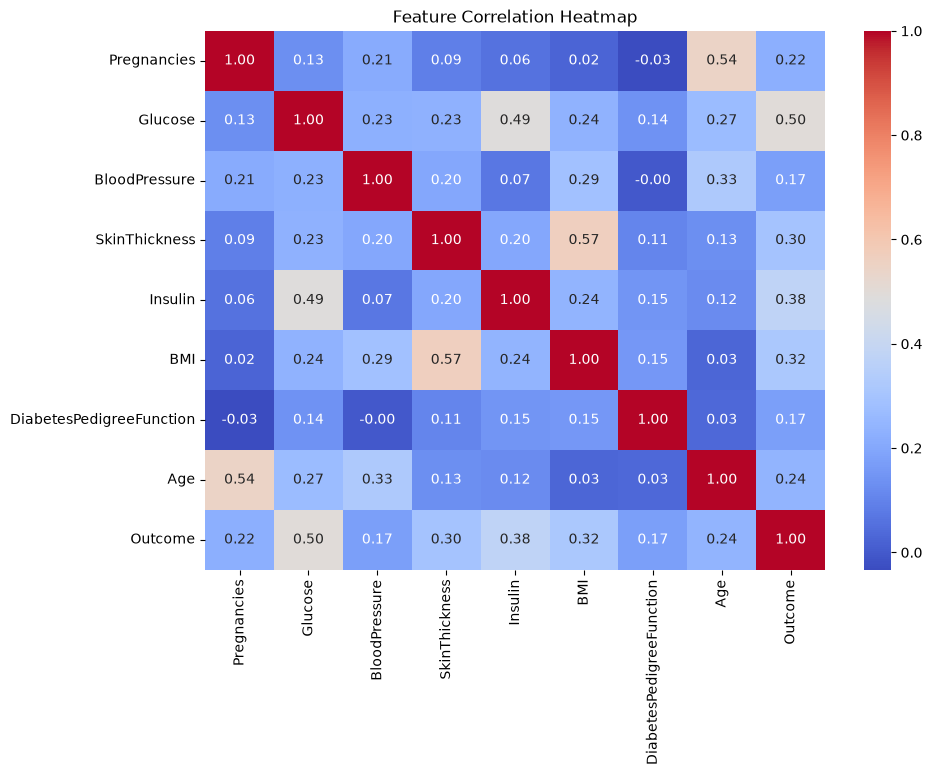

In [13]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

In [14]:
print(correlation["Outcome"].sort_values(ascending=False))

Outcome                     1.000000
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


In [15]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[features]
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (614, 8)
Scaled testing shape: (154, 8)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [19]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [21]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)
y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [22]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [23]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM trained successfully!")

SVM trained successfully!


d:\Downloads\Diabetes-risk-prediction\Diabetes-risk-prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [24]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

models_predictions = {
    "Logistic Regression": (y_pred_logistic, y_prob_logistic),
    "Decision Tree": (y_pred_tree, y_prob_tree),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "SVM": (y_pred_svm, y_prob_svm),
    "XGBoost": (y_pred_xgb, y_prob_xgb)
}

for name, (y_pred, y_prob) in models_predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,XGBoost,0.876623,0.830189,0.814815,0.822430,0.953704
2,Random Forest,0.863636,0.811321,0.796296,0.803738,0.948333
1,Decision Tree,0.824675,0.754717,0.740741,0.747664,0.912130
3,SVM,0.837662,0.763636,0.777778,0.770642,0.897407
0,Logistic Regression,0.707792,0.588235,0.555556,0.571429,0.826296


In [26]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

xgb_cv = cross_validate(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("XGBoost Cross-Validation Results")
print("---------------------------------")
print("Accuracy :", xgb_cv["test_accuracy"].mean())
print("Precision:", xgb_cv["test_precision"].mean())
print("Recall   :", xgb_cv["test_recall"].mean())
print("F1       :", xgb_cv["test_f1"].mean())
print("ROC-AUC  :", xgb_cv["test_roc_auc"].mean())

XGBoost Cross-Validation Results
---------------------------------
Accuracy : 0.8815720227484933
Precision: 0.8479552504762589
Recall   : 0.8062893081761006
F1       : 0.8262569412567282
ROC-AUC  : 0.9495136268343817


In [27]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 150, 200, 250, 300],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 1.0, 'n_estimators': 150, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}

Best CV ROC-AUC:
0.9529291251384274


In [28]:
best_xgb = random_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Test Results")
print("--------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1-Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tuned))

Tuned XGBoost Test Results
--------------------------
Accuracy : 0.8766233766233766
Precision: 0.8301886792452831
Recall   : 0.8148148148148148
F1-Score : 0.822429906542056
ROC-AUC  : 0.9574074074074074


Confusion Matrix:
[[91  9]
 [10 44]]


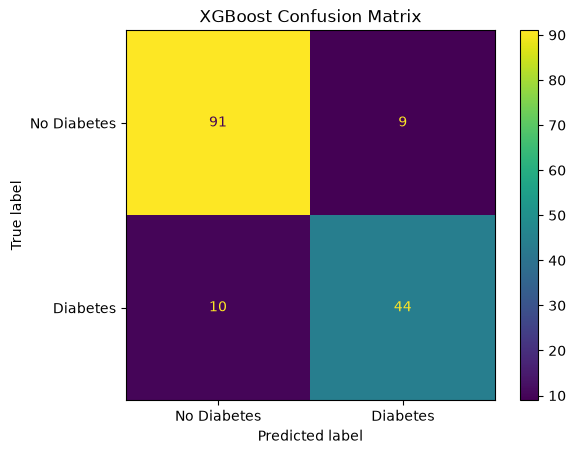

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

xgb_cv = cross_validate(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("XGBoost 5-Fold Cross-Validation")
print("--------------------------------")
print("Accuracy :", round(xgb_cv["test_accuracy"].mean(), 4))
print("Precision:", round(xgb_cv["test_precision"].mean(), 4))
print("Recall   :", round(xgb_cv["test_recall"].mean(), 4))
print("F1-Score :", round(xgb_cv["test_f1"].mean(), 4))
print("ROC-AUC  :", round(xgb_cv["test_roc_auc"].mean(), 4))

XGBoost 5-Fold Cross-Validation
--------------------------------
Accuracy : 0.8816
Precision: 0.848
Recall   : 0.8063
F1-Score : 0.8263
ROC-AUC  : 0.9495


In [31]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2]
}

xgb_tuning = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=1
)

xgb_tuning.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_tuning.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(xgb_tuning.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.8}

Best Cross-Validation ROC-AUC:
0.9513


In [32]:
best_xgb = xgb_tuning.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Test Results")
print("--------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_tuned), 4))
print("Precision:", round(precision_score(y_test, y_pred_tuned), 4))
print("Recall   :", round(recall_score(y_test, y_pred_tuned), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_tuned), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_tuned), 4))

Tuned XGBoost Test Results
--------------------------
Accuracy : 0.8636
Precision: 0.8
Recall   : 0.8148
F1-Score : 0.8073
ROC-AUC  : 0.9533


In [33]:
from sklearn.metrics import classification_report, confusion_matrix

print("Original XGBoost Classification Report")
print("----------------------------------------")

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["No Diabetes", "Diabetes"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Original XGBoost Classification Report
----------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.90      0.91      0.91       100
    Diabetes       0.83      0.81      0.82        54

    accuracy                           0.88       154
   macro avg       0.87      0.86      0.86       154
weighted avg       0.88      0.88      0.88       154

Confusion Matrix:
[[91  9]
 [10 44]]


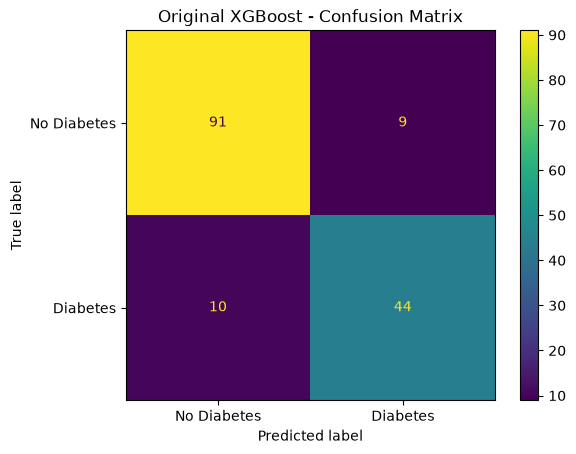

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_original = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_original,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Original XGBoost - Confusion Matrix")
plt.show()

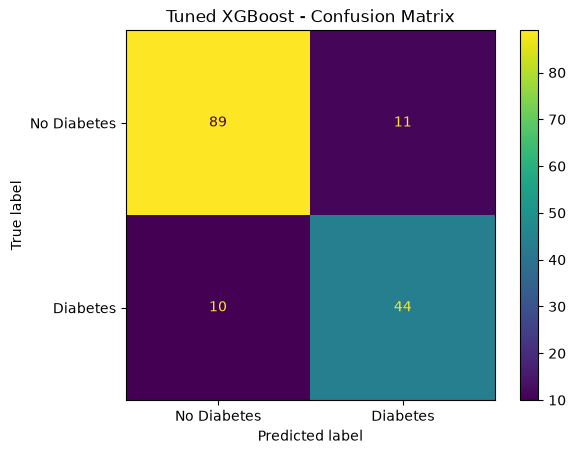

In [35]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Tuned XGBoost - Confusion Matrix")
plt.show()

In [36]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                    Feature  Importance
4                   Insulin    0.323579
3             SkinThickness    0.163291
1                   Glucose    0.137937
7                       Age    0.102208
5                       BMI    0.073429
6  DiabetesPedigreeFunction    0.070700
2             BloodPressure    0.065024
0               Pregnancies    0.063833


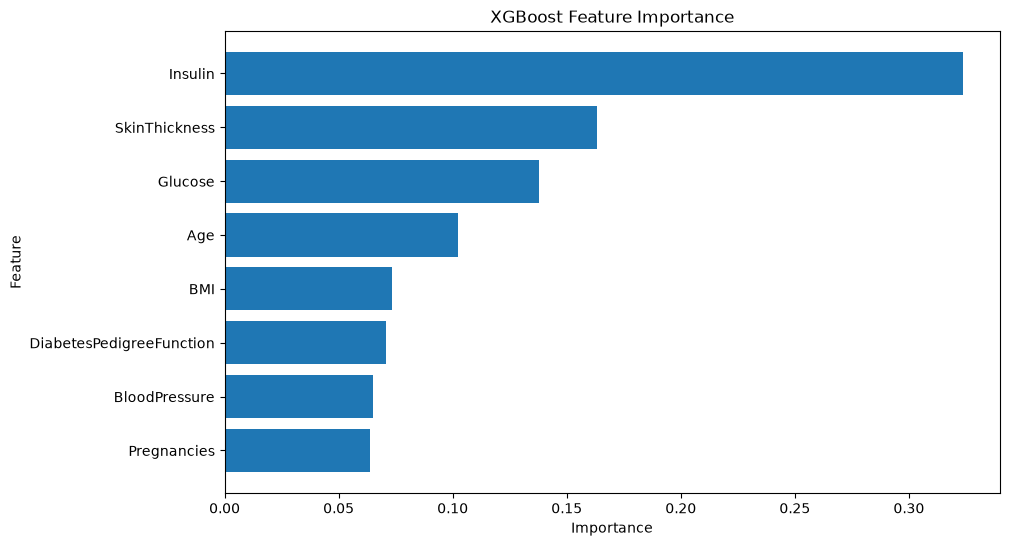

In [37]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [9]:
required_features = [
    "Glucose",
    "BloodPressure",
    "BMI",
    "Age",
    "Insulin"
]

X5 = df[required_features]
y5 = df["Outcome"]

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5,
    y5,
    test_size=0.20,
    random_state=42,
    stratify=y5
)

print("5-feature training:", X5_train.shape)
print("5-feature testing:", X5_test.shape)

5-feature training: (614, 5)
5-feature testing: (154, 5)


In [10]:
xgb_5 = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_5.fit(X5_train, y5_train)

y5_pred = xgb_5.predict(X5_test)
y5_prob = xgb_5.predict_proba(X5_test)[:, 1]

print("5-feature XGBoost trained successfully!")

5-feature XGBoost trained successfully!


In [40]:
from xgboost import XGBClassifier

In [41]:
print("5-Feature XGBoost Results")
print("------------------------")
print("Accuracy :", round(accuracy_score(y5_test, y5_pred), 4))
print("Precision:", round(precision_score(y5_test, y5_pred), 4))
print("Recall   :", round(recall_score(y5_test, y5_pred), 4))
print("F1-Score :", round(f1_score(y5_test, y5_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y5_test, y5_prob), 4))

5-Feature XGBoost Results
------------------------
Accuracy : 0.8831
Precision: 0.8333
Recall   : 0.8333
F1-Score : 0.8333
ROC-AUC  : 0.9565


In [42]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring5 = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

xgb5_cv = cross_validate(
    xgb_5,
    X5,
    y5,
    cv=cv5,
    scoring=scoring5
)

print("5-Feature XGBoost 5-Fold Cross-Validation")
print("------------------------------------------")
print("Accuracy :", round(xgb5_cv["test_accuracy"].mean(), 4))
print("Precision:", round(xgb5_cv["test_precision"].mean(), 4))
print("Recall   :", round(xgb5_cv["test_recall"].mean(), 4))
print("F1-Score :", round(xgb5_cv["test_f1"].mean(), 4))
print("ROC-AUC  :", round(xgb5_cv["test_roc_auc"].mean(), 4))

5-Feature XGBoost 5-Fold Cross-Validation
------------------------------------------
Accuracy : 0.8881
Precision: 0.8454
Recall   : 0.8324
F1-Score : 0.8382
ROC-AUC  : 0.951


In [43]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

df = pd.read_csv("../dataset/diabetes_cleaned.csv")

features = ["Glucose", "BloodPressure", "BMI", "Age", "Insulin"]

X = df[features]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

final_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

final_model.fit(X_train, y_train)

print("FINAL MODEL TRAINED ✅")

FINAL MODEL TRAINED ✅


In [44]:
import joblib

joblib.dump(final_model, "../models/diabetes_model.pkl")

print("Model saved successfully! ✅")

Model saved successfully! ✅


In [45]:
import pandas as pd

patient = pd.DataFrame([{
    "Glucose": 150,
    "BloodPressure": 80,
    "BMI": 32,
    "Age": 45,
    "Insulin": 120
}])

probability = final_model.predict_proba(patient)[0][1]
risk_percentage = probability * 100

print(f"Risk Score: {risk_percentage:.2f}%")

Risk Score: 75.39%


In [46]:
if risk_percentage >= 70:
    risk_level = "High Risk"
elif risk_percentage >= 40:
    risk_level = "Moderate Risk"
else:
    risk_level = "Low Risk"

print("Risk Level:", risk_level)

Risk Level: High Risk


In [47]:
def predict_diabetes_risk(glucose, blood_pressure, bmi, age, insulin):
    
    patient = pd.DataFrame([{
        "Glucose": glucose,
        "BloodPressure": blood_pressure,
        "BMI": bmi,
        "Age": age,
        "Insulin": insulin
    }])
    
    probability = final_model.predict_proba(patient)[0][1]
    risk_percentage = probability * 100
    
    if risk_percentage >= 70:
        risk_level = "High Risk"
    elif risk_percentage >= 40:
        risk_level = "Moderate Risk"
    else:
        risk_level = "Low Risk"
    
    return risk_percentage, risk_level

In [48]:
risk, level = predict_diabetes_risk(
    glucose=150,
    blood_pressure=80,
    bmi=32,
    age=45,
    insulin=120
)

print(f"Risk Score: {risk:.2f}%")
print(f"Risk Level: {level}")

Risk Score: 75.39%
Risk Level: High Risk


In [49]:
import joblib

model_data = {
    "model": final_model,
    "features": [
        "Glucose",
        "BloodPressure",
        "BMI",
        "Age",
        "Insulin"
    ]
}

joblib.dump(model_data, "../models/diabetes_model.pkl")

print("Final model package saved successfully! ✅")

Final model package saved successfully! ✅


In [50]:
loaded_data = joblib.load("../models/diabetes_model.pkl")

loaded_model = loaded_data["model"]
loaded_features = loaded_data["features"]

print("Features expected by model:")
print(loaded_features)

Features expected by model:
['Glucose', 'BloodPressure', 'BMI', 'Age', 'Insulin']


In [51]:
patient = pd.DataFrame([{
    "Glucose": 150,
    "BloodPressure": 80,
    "BMI": 32,
    "Age": 45,
    "Insulin": 120
}])

risk = loaded_model.predict_proba(patient)[0][1] * 100

print(f"Risk Score: {risk:.2f}%")

Risk Score: 75.39%


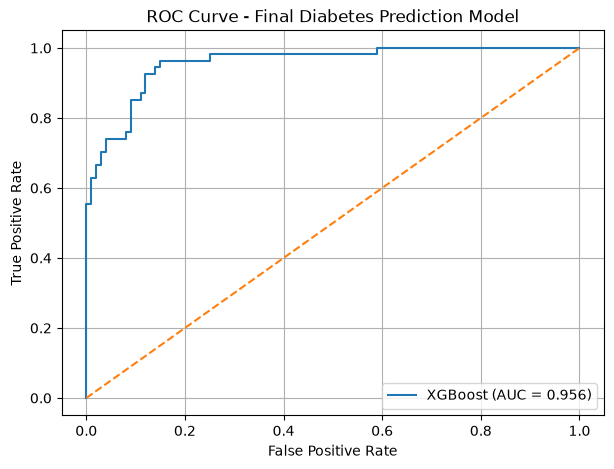

ROC-AUC Score: 0.9565


In [52]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

# Load dataset
df = pd.read_csv("../dataset/diabetes_cleaned.csv")

# Load your saved final model
model_data = joblib.load("../models/diabetes_model.pkl")
model = model_data["model"]

# Use the same 5 features and same test split as your notebook
features = ["Glucose", "BloodPressure", "BMI", "Age", "Insulin"]

X = df[features]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Predictions
y_prob = model.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Diabetes Prediction Model")
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

In [53]:
import sys
print(sys.executable)

d:\Downloads\Diabetes-risk-prediction\Diabetes-risk-prediction\.venv\Scripts\python.exe


         Feature  Importance
4        Insulin    0.454007
0        Glucose    0.187455
3            Age    0.137259
2            BMI    0.122733
1  BloodPressure    0.098547


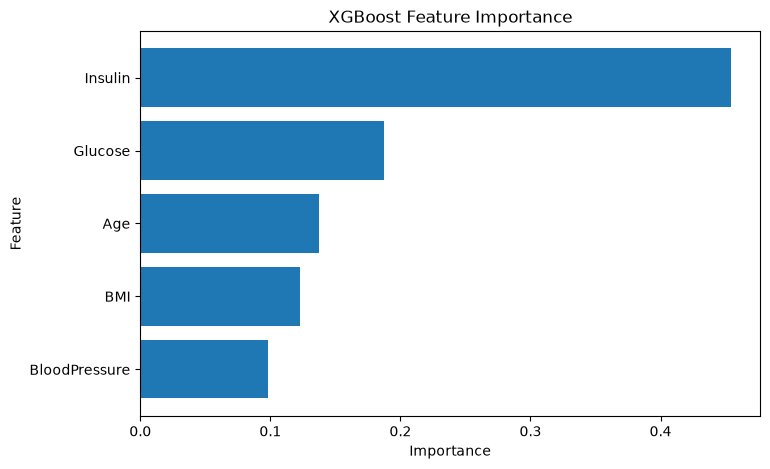

In [54]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Load saved final model
model_data = joblib.load("../models/diabetes_model.pkl")
model = model_data["model"]
features = model_data["features"]

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from your final XGBoost model
feature_importance = pd.DataFrame({
    "Feature": xgb_5.feature_names_in_,
    "Importance": xgb_5.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the actual values
print(feature_importance)

         Feature  Importance
4        Insulin    0.454007
0        Glucose    0.187455
3            Age    0.137259
2            BMI    0.122733
1  BloodPressure    0.098547
